In [19]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) #Ignora advertencias futuras para que la salida no se llene de mensajes no importantes.
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"#Indica a TensorFlow que use la GPU número 1, esto con el fin de poder el codigo si tenemos mas de una GPU
#y asignar una particular.
import pandas as pd 
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import sequence #sequence: aplicamos padding a secuencias
#Importa funciones útiles para preprocesar secuencias, especialmente:
#sequence.pad_sequences(...)
#Se uso para que el modelo, de todas las secuencias de entrada tengan la misma longitud
#(9 pasos temporales por muestra)=obligatorio para alimentar una red LSTM.
from tensorflow.keras import backend as K #K:funciones internas como limpiar memoria de la GPU
from tensorflow.keras import __version__
from tensorflow import keras
from tensorflow.keras import layers
#Importa las capas neuronales que usarás para construir tu red. Incluye:
#Input: para definir la forma de entrada
#Conv1D: capa convolucional 1D (ideal para series temporales)
#LSTM: capa de memoria a largo plazo
#Dense: capa totalmente conectada
from tensorflow.keras import activations #Permite acceder directamente a funciones de activación como relu, sigmoid, elu, etc.
from tensorflow.keras.optimizers import Adam #Importa el optimizador Adam, que es el algoritmo que ajusta los pesos del modelo durante el entrenamiento. 
#Es un método muy eficiente para redescomplejas y largas
import matplotlib.pyplot as plt
from IPython.display import SVG,clear_output
from sklearn.model_selection import train_test_split #Permite dividir el dataset en entrenamiento, validación y prueba.

tf.random.set_seed(7) #Se fijó una semilla aleatoria (tf.random.set_seed(7)) 
#para garantizar la reproducibilidad de los resultados durante el entrenamiento del modelo.

print('Using Keras version:', __version__, 'backend:', K.backend()) #Muestra la versión de Keras usada y el backend de computación (tensorflow)

Using Keras version: 3.12.0 backend: tensorflow


In [20]:
## Clase personalizada para visualizar la pérdida de entrenamiento y validación en tiempo real
class PlotLosses(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        # Se ejecuta al inicio del entrenamiento
        # Inicializa contadores y listas para guardar las pérdidas
        self.i = 0 # contador de épocas
        self.x = [] # eje X (épocas)
        self.losses = [] # pérdida de entrenamiento por época
        self.val_losses = [] # pérdida de validación por época

        self.fig = plt.figure() # figura para graficar

        self.logs = [] # historial de logs


    def on_epoch_end(self, epoch, logs={}):  # Se ejecuta al final de cada época
        # Guarda los valores de pérdida y validación
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.i += 1 # incrementa el contador de época
    
        clear_output(wait=True) # Limpia la salida anterior (solo en notebooks)
        
        plt.plot(self.x, self.losses, label="loss")
        plt.plot(self.x, self.val_losses, label="v_loss")
        plt.xlabel("Épocas")               
        plt.ylabel("Pérdida (Loss)")     
        plt.title("Evolución de la pérdida durante el entrenamiento")  
        plt.legend()
        plt.show()

         
#Crear una instancia del callback para usarlo en el entrenamiento
plot_losses = PlotLosses()


In [21]:

alpha_diversity = pd.read_csv(r'C:\Users\Emiliano\Desktop\CodigosTesis\Training\Training\community_state_types\cst_valencia.csv')#diversidad de la microbiota por muestra
community = pd.read_csv(r'C:\Users\Emiliano\Desktop\CodigosTesis\Training\Training\community_state_types\cst_valencia_w_taxons.csv') #perfiles comunitarios con taxones
metadata = pd.read_csv(r'C:\Users\Emiliano\Desktop\CodigosTesis\Training\Training\metadata\metadata.csv') #información clínica (incluye la edad)
phylotypes = pd.read_csv(r'C:\Users\Emiliano\Desktop\CodigosTesis\Training\Training\phylotypes\phylotype_nreads.1e_1.csv') #abundancias de tipos filogenéticos por muestra

metadata.loc[metadata.age=='Unknown','age']='99' #Se reemplazo el texto 'Unknown' por '99' para que se pueda procesar numéricamente, mejor para la memoria del modelo
CatVal = ["Below_18","Above_38","99","29-38","18_to_28"]
metadata_num = metadata.loc[~metadata["age"].isin(CatVal)] #Se separan las filas que NO están ya categorizadas (números de edad sin agrupar) para recodificarlas.
metadata_num = metadata_num.astype({"age": float})
metadata_num.age = metadata_num.age.round()
metadata_num = metadata_num.astype({"age": int}) #Convierte la edad a número (por si viene como texto), la redondea y la deja como entero.

bins = pd.IntervalIndex.from_tuples([(0, 18), (18, 28), (28, 38),(38,80)]) #Crea rangos de edad y categoriza las edades numéricas en esos rangos.
metadata_num["age"] = pd.cut(metadata_num["age"], bins)
metadata_num['age'] = metadata_num['age'].astype(str)

metadata_num.loc[metadata_num.age=='(0, 18]','age']="Below_18"
metadata_num.loc[metadata_num.age=='(18, 28]','age']="18_to_28" #Reemplaza los nombres de los intervalos con etiquetas personalizadas
metadata_num.loc[metadata_num.age=='(28, 38]','age']="29-38"
metadata_num.loc[metadata_num.age=='(38, 80]','age']="Above_38"

metadata_car = metadata.loc[metadata["age"].isin(CatVal)]
metadata = pd.concat([metadata_num, metadata_car], axis=0, ignore_index=True)
#Vuelve a unir los datos categorizados manualmente (CatVal) con los que acabamos de recodificar (metadata_num).


combineddata = alpha_diversity.merge(community, left_on='specimen', right_on='specimen')
combineddata = combineddata.merge(metadata, left_on='specimen', right_on='specimen')
combineddata = combineddata.merge(phylotypes, left_on='specimen', right_on='specimen')
#Realiza tres uniones (merge) consecutivas sobre la columna común specimen para consolidar todos los datasets en una sola tabla final: combineddata.

##############################################

X = combineddata

print(X.shape)
print(X.columns)


#Para construir el conjunto de datos final utilizado en el modelo, se integraron cuatro fuentes de información: 
#alpha_diversity, community, metadata y phylotypes. A través de uniones sucesivas (merges) usando el identificador común specimen, 
#se consolidó toda la información relevante por muestra en un único DataFrame. Antes se hizo, 
#que la variable age fue transformada de valores numéricos a categorías de edad estandarizadas, 
#lo que permitió homogeneizar el formato de los datos. El resultado fue una matriz estructurada,
#donde cada fila representa una muestra biológica única y cada columna aporta información microbiana o clínica,  type: ignore
#lista para ser utilizada como entrada en el modelo de aprendizaje profundo


(1895, 10158)
Index(['specimen', 'CST_x', 'subCST_x', 'score_x', 'I-A_sim_x', 'I-B_sim_x',
       'II_sim_x', 'III-A_sim_x', 'III-B_sim_x', 'IV-A_sim_x',
       ...
       'pt__09708', 'pt__09709', 'pt__09710', 'pt__09711', 'pt__09712',
       'pt__09713', 'pt__09714', 'pt__09715', 'pt__09716', 'pt__09717'],
      dtype='object', length=10158)


In [22]:
Cols1 = X.columns[1:422]
Cols2 = ["collect_wk"]
Cols3 = X.columns[435:len(X.columns)]

ColstoGet = np.append(Cols1,Cols2)
ColstoGet = np.append(ColstoGet,Cols3)

ColstoGet = ColstoGet[ColstoGet != 'index_y']
ColstoGet = ColstoGet[ColstoGet != 'CST']
ColstoGet = ColstoGet[ColstoGet != 'subCST']

ColstoGet = ColstoGet[ColstoGet != 'NIH Ethnicity Category']
ColstoGet = ColstoGet[ColstoGet != 'NIH Racial Category']
ColstoGet = ColstoGet[ColstoGet != 'race']

ColstoGet_pd = pd.DataFrame(ColstoGet)
ColstoGet_pd.to_csv("Predictors.csv")

#Este bloque de codigo hace lo siguiente, selecciona columnas específicas del DataFrame X (X = combineddata) que es el resultado de combinar todos los archivos cargados: 
# diversidad, comunidad, metadata y filotipos, esto con el fin de pofer definir el conjunto de variables predictoras/prtedictivas que se usará para entrenar el modelo LSTM.

#Cols1 = X.columns[1:422]
#Selecciona las primeras 421 columnas, omitiendo la primera (specimen). Estas columnas generalmente contienen métricas de diversidad alfa y otros features derivados.

#Cols2 = ["collect_wk"]
#Incluye manualmente la semana de recolección, una variable temporal relevante para el análisis.

#Cols3 = X.columns[435:len(X.columns)]
#Agrega desde la columna 435 en adelante, que corresponde a los filotipos (variables microbianas específicas) del archivo phylotypes.

#ColstoGet = np.append(...)
#Une Cols1, Cols2, y Cols3 en un solo arreglo llamado ColstoGet.

#ColstoGet = ColstoGet[ColstoGet != ...]
#Elimina columnas categóricas o poco informativas que no se desean en el modelo como :
#index_y: índice redundante de la fusión de archivos.
#CST, subCST son etiquetas de comunidad, que podrían sesgar el modelo si ya resumen el microbioma.
#race, NIH Racial Category, NIH Ethnicity Category: variables demográficas que se están omitiendo.
#No son biológicas ni clínicas directamente.
#introducen sesgo, segun chat y un amigo bilogo, no son recomendables si trabajamos solo con micrtobiomavaginal
#Por lo tanto no aporttan nada al LSTM


#ColstoGet_pd = pd.DataFrame(ColstoGet)
#Convertimos el arreglo final de nombres de columnas en un DataFrame de una sola columna.

#ColstoGet_pd.to_csv("Predictors.csv")
#Guarda esta lista de columnas seleccionadas como archivo CSV, útil para revisar o reutilizar después.

In [23]:
Predictors = pd.read_csv('Predictors.csv').reset_index()
Predictors = Predictors.iloc[:,2]
Predictors = Predictors.values #transforma la Serie de pandas en un arreglo NumPy, lo cual facilita concatenaciones posteriores.
Predictors = np.append(Predictors,'participant_id')  #participant_id es esencial para agrupar muestras por persona. 
#se necesita para formar secuencias individuales en el modelo LSTM (una secuencia por persona).
ColsTraining = ['was_early_preterm','project'] 
Predictors = np.append(Predictors,ColsTraining)
#was_early_preterm: es la variable objetivo del modelo (etiqueta: si hubo parto prematuro temprano).
#project: sirve para controlar estudios diferentes dentro del dataset

##############################################

print(Predictors.shape) # cuántas columnas hay en total, útil para verificar antes de filtrar el DataFrame con ellas.

(10145,)


In [24]:
X_ids = combineddata["specimen"] # Extrae los IDs de muestra
X = X.loc[:, Predictors] #Selecciona solo las columnas que están en la lista de Predictors

X["specimen_person"] = X_ids.str.split('-').str[0]  #Crea una nueva columna para identificar a la persona (grupo de muestras)
                                                    # Se toma el identificador antes del guion en 'specimen'
X = X.loc[:, X.dtypes.apply(lambda dt: np.issubdtype(dt, np.number)) | (X.columns == "specimen_person")]
# Elimina las columnas no numéricas, excepto 'specimen_person' (que es necesaria para agrupar)

# Verifica que columnas clave estén presentes; si no, las recupera del DataFrame original
required_cols = ['was_early_preterm', 'participant_id']
for col in required_cols:
    if col not in X.columns:
        X[col] = combineddata[col]  # recupera de la fuente original si se perdió en el filtrado (se perdio pero eso esto jaja)

persons = X["specimen_person"].unique() # Lista de personas únicas (cada una con múltiples muestras)


# Iniciamos las listas para almacenar secuencias y etiquetas importante incia por asi decirlo el podemlo LSTM
lstmDat_X = []
lstmDat_y = []

for person in persons:
    loopDat = X.loc[X["specimen_person"] == person] # Filtra todas las muestras de esa persona

    loopy = loopDat["was_early_preterm"].unique() # Obtiene la etiqueta (parto prematuro), esta cosa asume que = 1 valor por persona
    loopDat = loopDat.drop(['specimen_person', 'was_early_preterm', 'participant_id'], axis=1) # Elimina columnas no predictoras antes de entrenar,
    #sirve para no sobre cargar el modelo, no da falsos, estos solo son por asi decirlo identificadores, lo que realmente buscamos es poder saber el microbioma, 
    #puede ser capaz de generalizar a nuevos pacientes.

    loopX = loopDat.to_numpy()  # Entra NumPy y zonvierte a array

    lstmDat_X.append(loopX) # Almacena la secuencia y su etiqueta
    lstmDat_y.append(loopy) # Almacena la secuencia y su etiqueta

lstmDat_y_flat = [item for sublist in lstmDat_y for item in sublist] # Aplana la lista de etiquetas para que tenga forma (n,)
lstmDat_y_flat = np.where(np.array(lstmDat_y_flat) == True, 1, 0) # Convierte etiquetas booleanas a enteros 0/1

max_sequence_length = 9  
#Define la longitud máxima de secuencia temporal que tendrá cada entrada al modelo LSTM.
#cada secuencia representa a una persona (importante) y cada paso temporal es una muestra vaginal recolectada en una semana distinta del embarazo.
#La pregunta ¿Por qué 9?, se determino (por inspección) que como máximo hay 9 muestras por persona en el dataset. Si alguien tiene menos, se "rellena" para que pueda ser corrido correctamente.



X_padded = sequence.pad_sequences(lstmDat_X, maxlen=max_sequence_length)
#Esta función de Keras hace padding de secuencias, osea:
# que odas las secuencias en lstmDat_X pueden tener longitudes distintas (por ejemplo: persona A tiene 6 muestras, persona B tiene 9, persona C tiene 3).
#Los modelos LSTM requieren OBLIGATORIAMENTE que todas las secuencias tengan la misma longitud para poder procesarlas en batch (si no son de la misma longuitud se rompe el modelo y ya no es un LSTM).
#Lo que hace pad_sequences es rellenar con ceros las secuencias más cortas hasta que todas tengan longitud 9 (conveniencia, no les agrega valores inventados, el CERO(0) solocompleta con un valor nulo).


# Verifica la forma final del dataset  en 3D gracias a KERAS PADDING 
print("X_padded shape:", X_padded.shape)
print("Etiquetas:", len(lstmDat_y_flat))



X_padded shape: (616, 9, 10138)
Etiquetas: 616


In [26]:
# Aplanamos también la lista de proyectos
# Esto permite hacer una separación estratificada por cohorte
lstmDat_p_flat = [
    combineddata.loc[combineddata["specimen"].str.startswith(person), "project"].unique()[0]
    for person in X["specimen_person"].unique()
]
lstmDat_p_flat = np.array(lstmDat_p_flat)

#la verdad es que iba arriba pero se me olvido ponerlo 

X_train, X_test, y_train, y_test = train_test_split(
    X_padded, 
    lstmDat_y_flat,
    stratify=lstmDat_p_flat) # asegura balance de clases por cohorte (conjunto, serie)

# Divimod el dataset en entrenamiento y prueba esto con sklearn, se necesita ya que tensorflow no lo hace, necesita esa herramienta
# - Usa stratify para asegurar que las clases (parto prematuro vs no) estén balanceadas en ambos conjuntos, si no estan balanceadas.
# - lstmDat_p_flat contiene el "proyecto" o cohorte → se usa como estratificador para mantener distribución representativa

# Divimosaún más el conjunto de entrenamiento en entrenamiento y validación
# Esto es útil para monitorear el desempeño del modelo durante el entrenamiento, se aprendio durante el proceso de los ML anteriores.

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train)



##########################################

print(X_train.shape) # número de personas, pasos de tiempo, variables
print(X_val.shape) # conjunto de validación
print(X_test.shape) # conjunto de prueba (evaluación final)

(346, 9, 10138)
(116, 9, 10138)
(154, 9, 10138)


In [29]:
K.clear_session() # Limpia la sesión de Keras/TensorFlow por si hay modelos previos cargados en GPU/memoria, como eran fallos y errores, luego no me permiotia correrlo


# Definmos la entrada del modelo: una secuencia de longitud 9 (max_sequence_length), se definio previamente
#     con 10144 variables predictoras en cada paso temporal se ve arriba (resulatdo del bloque de codigo anterior)
x=layers.Input(shape=(max_sequence_length,10138))

#En términos sencillos, la convolución es una operación matemática que combina dos funciones o conjuntos de datos (como una imagen y un filtro) 
# para producir una tercera función o imagen que representa cómo la forma de una es modificada por la otra. 
# Implica "deslizar" un filtro (también llamado núcleo o kernel) sobre los datos de entrada, 
# multiplicar los valores superpuestos y sumar los productos para crear un nuevo valor en la salida. ########Internet



# Capa convolucional 1D:
######    Detecta patrones locales en cada secuencia (tipo extracción de características)
#########    Usa 16 filtros, tamaño de kernel 3 y activación 'elu' (más suave que ReLU)
model=layers.Conv1D(filters=16, kernel_size=3, padding='same', activation='elu')(x)

# ✅ Reducción de dimensionalidad con MaxPooling
model=layers.MaxPooling1D(pool_size=2)(model) 

# Capa LSTM (empezamos jajajaa risa mala):
######    Aprende la dinámica temporal en las secuencias
##########     100 unidades de memoria
model=layers.LSTM(100)(model)


# Bloque de capas para mejorar el entrenamiento
############## Activación no lineal → normalización → regularización (Dropout)
model=layers.LeakyReLU(100)(model)
model=layers.BatchNormalization()(model)
model=layers.Dropout(0.15)(model)

model=layers.LeakyReLU(100)(model)
model=layers.BatchNormalization()(model)
model=layers.Dropout(0.15)(model)

model=layers.LeakyReLU(100)(model)
model=layers.BatchNormalization()(model)
model=layers.Dropout(0.15)(model)


# Capa de salida:
#####     1 sola neurona (salida binaria: parto prematuro o no)
########    Activación sigmoide para predecir probabilidad

model=layers.Dense(1, activation='sigmoid')(model)

myModel=keras.Model(x,model) # Crea el modelo completo a partir de la entrada y la salida final

##############################################

print(myModel.summary()) # Muestra un resumen de la arquitectura del modelo

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9, 10138)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 9, 16)          │       486,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        46,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 534,741 (2.04 MB)

 Trainable params: 534,141 (2.04 MB)

 Non-trainable params: 600 (2.34 KB)

None


In [ ]:
# ¿Qué es ELU y por qué no ReLU?
# --------------------------------
# ReLU (Rectified Linear Unit) es una función de activación que convierte todos los valores negativos en cero:
#     f(x) = max(0, x)
# Es simple y eficiente, pero tiene un problema: los valores negativos quedan muertos y no aprenden ("dead neurons").

# ELU (Exponential Linear Unit) en cambio:
#     f(x) = x   si x > 0
#     f(x) = alpha * (exp(x) - 1) si x <= 0
# ELU permite que los valores negativos tengan una pequeña pendiente, lo cual mejora la estabilidad y aprendizaje
# Es más suave, especialmente en redes profundas

# ¿Qué hace MaxPooling1D?
# --------------------------
# MaxPooling1D reduce la dimensión de salida tomando el valor máximo en una ventana.
# Ayuda a:
#  Reducir el tamaño de las secuencias (menos carga computacional)
#  Enfocarse en las características más importantes (mayor robustez)
# En este caso, reduce a la mitad la longitud temporal después de la convolución.

# ¿Qué son las "100 unidades de memoria" en LSTM?
# --------------------------------------------------
# Una capa LSTM (Long Short-Term Memory) tiene "celdas de memoria" que recuerdan información a través del tiempo.
#  Las 100 unidades son como 100 neuronas que pueden aprender distintos patrones temporales.
#  Cuantas más unidades, mayor capacidad de memoria → pero también mayor riesgo de sobreajuste si hay pocos datos.

# ¿Por qué usar 3 bloques de LeakyReLU + BatchNorm + Dropout?
# --------------------------------------------------------------
# Cada bloque cumple un propósito:
#  LeakyReLU(100): función de activación → evita que las neuronas mueran como con ReLU puro.
#  BatchNormalization(): normaliza las activaciones por batch → acelera el entrenamiento y mejora estabilidad.
# Dropout(0.15): desactiva aleatoriamente el 15% de las neuronas → previene el sobreajuste.

# Por que usar 3 bloques:
#  Aumenta la profundidad de la red para que aprenda patrones más complejos si son más es conveniente, pero no es muy pesado el modelo.
#  Da redundancia y regularización → más robustez sin aumentar mucho el costo computacional(mejor para las computadoras, en mi caso no es necesario se puso para ser compartido este codigo).

# ℹ¿Qué es la activación sigmoide al final?
# ------------------------------------------
# La capa de salida tiene una sola neurona (porque es clasificación binaria).
# La función "sigmoid" transforma la salida a un valor entre 0 y 1 → representa la probabilidad de clase positiva.
# Ejemplo:
# - 0.95 → el modelo cree que hay un 95% de probabilidad de parto prematuro.
# - 0.12 → baja probabilidad, se predice clase negativa.


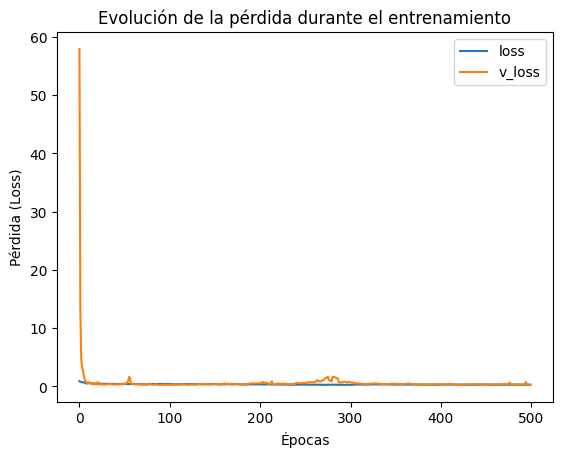

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8699 - loss: 0.2857 - val_accuracy: 0.8448 - val_loss: 0.3104


In [30]:
# Hiperparámetros de entrenamiento
init_lr = 1e-3 # Tasa de aprendizaje inicial para el optimizador
epochs = 500 # Número total de épocas (vueltas sobre todo el dataset)
opt = Adam(learning_rate=init_lr) # Optimizador Adam: adapta la tasa de aprendizaje por parámetro


myModel.compile(
    optimizer=opt, # Algoritmo de optimización
    loss='binary_crossentropy', # Función de pérdida para clasificación binaria
    metrics=['accuracy']  # Métrica a evaluar durante entrenamiento y validación
)

checkpoint_filepath = './best_model.weights.h5' # Definir el archivo donde se guardarán los pesos del mejor modelo (futuras pruebas)

#  Callback para guardar los mejores pesos (modelo con mayor val_accuracy)
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath, # Ruta para guardar
    save_weights_only=True,  #Guardar solo pesos (no la arquitectura)
    monitor='val_accuracy', # Métrica a seguir
    mode='max',
    save_best_only=True # Solo guardar el mejor modelo
)


myModel.fit(
    X_train, y_train, # Datos de entrenamiento
    epochs=epochs, # Número de épocas
    validation_data=(X_val, y_val), # Datos de validación
    batch_size=32,   # Tamaño de batch
    callbacks=[plot_losses, model_checkpoint_callback] # Llamadas automáticas durante entrenamiento
)

myModel.load_weights(checkpoint_filepath) # Cargar los pesos del mejor modelo encontrado durante el entrenamiento


In [ ]:
# INTERPRETACIÓN DE LA GRÁFICA DE ENTRENAMIENTO
# 
# Esta gráfica muestra la evolución del error (loss) durante
# el entrenamiento del modelo:
#
# 🔵 'loss': pérdida (error) en los datos de entrenamiento
# 🟠 'val_loss': pérdida en los datos de validación
#
#  FASE INICIAL (épocas 0–10):
# - Caída rápida en loss y val_loss, como es esperado.
# - Picos altos en val_loss (hasta 35), lo que indica 
#   inestabilidad mientras el modelo aprende a predecir.
#
#  RESTO DEL ENTRENAMIENTO:
# - 'loss' se mantiene muy bajo y estable → buen aprendizaje.
# - 'val_loss' disminuye, pero tiene variaciones → el modelo 
#   no generaliza tan bien como memoriza.
#
#  FINAL DEL ENTRENAMIENTO (época 500):
# - Precisión en entrenamiento: 86.99%
# - Precisión en validación: 84.48%
# - La diferencia entre ambas sugiere un posible 
#   sobreajuste (overfitting leve).
#
# ✅ Conclusión: el modelo aprende, pero hay margen de mejora 
# en la capacidad de generalización.
#
# ############################################################


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Area under the ROC curve : 0.655637
         fpr       tpr     1-fpr        tf  thresholds
37  0.333333  0.647059  0.666667 -0.019608    0.167514


[Text(-10.0, 0, ''),
 Text(0.0, 0, ''),
 Text(10.0, 0, ''),
 Text(20.0, 0, ''),
 Text(30.0, 0, ''),
 Text(40.0, 0, ''),
 Text(50.0, 0, ''),
 Text(60.0, 0, ''),
 Text(70.0, 0, '')]

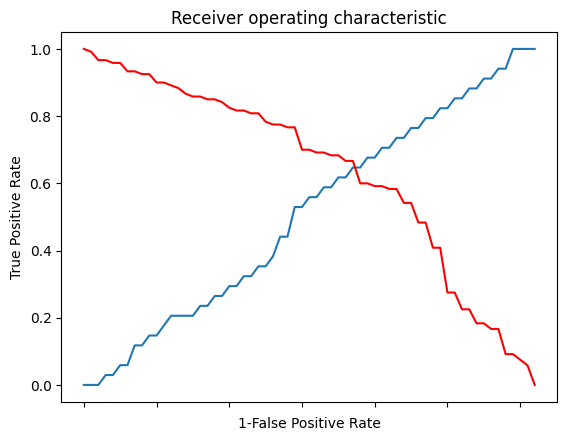

In [31]:


ypred = myModel.predict(X_test) # Generar predicciones probabilísticas con el modelo

from sklearn.metrics import roc_curve,auc # Calcular la curva ROC y el AUC (área bajo la curva)
import pylab as pl
fpr, tpr, thresholds =roc_curve(y_test, ypred) # Falsos positivos, verdaderos positivos y umbrales
roc_auc = auc(fpr, tpr) # Área bajo la curva

print("Area under the ROC curve : %f" % roc_auc)

# Encontrar el mejor umbral de clasificación
# Buscamos donde TPR - (1 - FPR) es cercano a cero (buen compromiso entre sensibilidad y especificidad)

i = np.arange(len(tpr)) # index para df
roc = pd.DataFrame({'fpr' : pd.Series(fpr, index=i),'tpr' : pd.Series(tpr, index = i), '1-fpr' : pd.Series(1-fpr, index = i), 'tf' : pd.Series(tpr - (1-fpr), index = i), 'thresholds' : pd.Series(thresholds, index = i)})

print(roc.iloc[(roc.tf-0).abs().argsort()[:1]])
# Imprimir el umbral óptimo
fig, ax = pl.subplots()
pl.plot(roc['tpr'])
pl.plot(roc['1-fpr'], color = 'red')
pl.xlabel('1-False Positive Rate')
pl.ylabel('True Positive Rate')
pl.title('Receiver operating characteristic')
ax.set_xticklabels([])


In [ ]:
# ------------------------------------------------------------------------------
# INTERPRETACIÓN DE LA GRÁFICA ROC (Receiver Operating Characteristic)
# ------------------------------------------------------------------------------

# Esta gráfica evalúa el rendimiento del modelo clasificando partos prematuros.

#  🔵 LÍNEA AZUL: True Positive Rate (TPR)
# ---------------------------------------
# También conocida como sensibilidad o recall.
# Indica cuántos de los partos prematuros reales el modelo detecta correctamente.
# Un TPR alto = el modelo detecta bien los positivos.

# 🔴 LÍNEA ROJA: 1 - False Positive Rate (1 - FPR)
# ------------------------------------------------
# Refleja qué tan bajo es el número de falsos positivos.
# Si está alta, significa que el modelo comete pocos errores de falsos positivos.

# OBJETIVO:
# Encontrar el punto donde ambas líneas están más cerca o se cruzan.
# Ese punto representa el mejor equilibrio entre detectar los positivos y evitar falsos positivos.
# Se define como el umbral óptimo de clasificación.

#  EJEMPLO DE RESULTADO IMPRESO:
#     fpr       tpr       1-fpr     tf         thresholds
#     0.3333    0.6471    0.6667   -0.0196     0.1675
# 
# El umbral óptimo es ≈ 0.1675
# tf = TPR - (1 - FPR) ≈ 0  → buen equilibrio

#  ÁREA BAJO LA CURVA ROC (AUC):
# AUC = 0.6556
# - Si AUC = 0.5 → el modelo no aprende nada (azar)
# - Si AUC = 1.0 → el modelo es perfecto
# - En este caso: AUC de 0.65 indica un desempeño moderado (mejor que azar)

#  CONCLUSIÓN:
# El modelo tiene una capacidad razonable para distinguir partos prematuros vs normales.
# Podría mejorarse, pero es funcional dependiendo del contexto clínico.


In [32]:
from sklearn.metrics import classification_report, confusion_matrix

optimal_threshold = roc.iloc[(roc.tf-0).abs().argsort()[:1]]['thresholds'].values[0]
print("Umbral óptimo:", optimal_threshold)

y_pred_binary = (ypred >= optimal_threshold).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_binary))

print("Reporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred_binary,
        target_names=["No prematuro", "Prematuro"]
    )
)

##El umbral óptimo fue determinado a partir de la curva ROC como el punto donde TPR − (1 − FPR) ≈ 0. 
#Con dicho umbral se calcularon precisión, sensibilidad (recall) y F1-score para cada clase.


Umbral óptimo: 0.16751358
Matriz de confusión:
[[80 40]
 [12 22]]
Reporte de clasificación:
              precision    recall  f1-score   support

No prematuro       0.87      0.67      0.75       120
   Prematuro       0.35      0.65      0.46        34

    accuracy                           0.66       154
   macro avg       0.61      0.66      0.61       154
weighted avg       0.76      0.66      0.69       154



In [ ]:
# ---------------------------------------------
#  INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN Y METRICAS
# ---------------------------------------------

# Matriz de confusión:
# [[80 40]
#  [12 22]]
#
# Significado:
# - 80: Verdaderos negativos → modelo predijo correctamente "No prematuro"
# - 40: Falsos positivos → modelo predijo "Prematuro", pero era "No prematuro"
# - 12: Falsos negativos → modelo predijo "No prematuro", pero era "Prematuro"
# - 22: Verdaderos positivos → modelo predijo correctamente "Prematuro"

# Reporte de clasificación:
#
# Clase           | Precisión | Recall | F1-score | Soporte
# -----------------------------------------------------------
# No prematuro    |   0.87    |  0.67  |   0.75   |   120
# Prematuro       |   0.35    |  0.65  |   0.46   |    34
#
# Métricas globales:
# - Accuracy        = 0.66
# - Macro avg       = 0.61
# - Weighted avg    = 0.69

# Significado de métricas:
# - Precisión (precision): De los que predijo como clase X, ¿cuántos lo eran?
#   → Baja precisión en "Prematuro" indica muchos falsos positivos.
# - Recall (sensibilidad): De los casos reales clase X, ¿cuántos detectó?
#   → Buen recall en "Prematuro" (0.65), lo cual es valioso en medicina.
# - F1-score: Equilibrio entre precisión y recall.
#   → Para "Prematuro", el F1-score es 0.46, muestra mejora respecto al azar.

# Comentario:
# - El modelo logra identificar muchos casos reales de parto prematuro (65%)
# - Pero comete errores al predecir prematuros que no lo son (solo 35% aciertos)
# - Esto puede ser aceptable si tu prioridad es no dejar pasar partos prematuros.
# - Se recomienda probar con técnicas de balanceo de clases (oversampling, pesos)


In [33]:
import pandas as pd
import numpy as np


results_df = pd.DataFrame({
    'true_label': y_test,
    'predicted_proba': ypred.flatten(),       
    'predicted_label': y_pred_binary.flatten()  
})

# Guardar en CSV
results_df.to_csv("predicciones_lstm_preterm.csv", index=False)

print("✅ Predicciones exportadas a 'predicciones_lstm_preterm.csv'")


✅ Predicciones exportadas a 'predicciones_lstm_preterm.csv'


In [34]:
from sklearn.metrics import classification_report


report_dict = classification_report(
    y_test,
    y_pred_binary,
    target_names=["No prematuro", "Prematuro"],
    output_dict=True
)


report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("metricas_clasificacion_lstm.csv", index=True)

print("✅ Métricas exportadas a 'metricas_clasificacion_lstm.csv'")


✅ Métricas exportadas a 'metricas_clasificacion_lstm.csv'


✅ Curva ROC guardada como 'curva_roc_lstm.png'


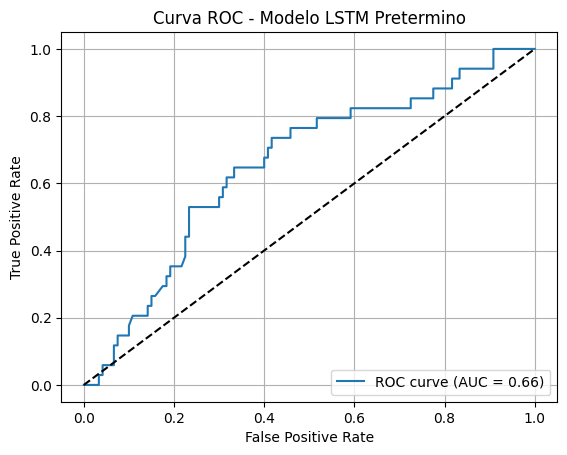

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Línea diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Modelo LSTM Pretermino')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("curva_roc_lstm.png", dpi=300)

print("✅ Curva ROC guardada como 'curva_roc_lstm.png'")


In [ ]:
# -----------------------------------------------------------
#  Interpretación de la curva ROC
# -----------------------------------------------------------
# Esta curva ROC (Receiver Operating Characteristic) compara:
#   - Eje X: Tasa de Falsos Positivos (False Positive Rate - FPR)
#   - Eje Y: Tasa de Verdaderos Positivos (True Positive Rate - TPR / Recall)
#
# La línea diagonal punteada (y = x) representa un modelo aleatorio (AUC = 0.5).
# Todo lo que esté por encima de esa línea indica que el modelo tiene poder predictivo.
#
# En esta gráfica:
# 🔹 El AUC (Area Under the Curve) es de aproximadamente 0.66.
#     - Esto indica que el modelo tiene una capacidad de discriminación **moderada**,
#       es decir, puede distinguir entre clases (prematuro / no prematuro)
#       con un rendimiento algo mejor que el azar.
#
# 🔸 Una curva más inclinada hacia la esquina superior izquierda representaría
#     un mejor modelo (TPR alto, FPR bajo).
#
#  En resumen:
# - El modelo es funcional, pero aún hay margen de mejora.
# - Posibles mejoras: ajustar hiperparámetros, balancear clases, agregar features, etc.


In [26]:

myModel.save("lstm_preterm3.h5")
